In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

In [56]:
df = pd.read_csv("smartcart_customers.csv")
#df.isnull().sum()

# Data Preprocessing

### 1. Handling Missing Values 

In [57]:
df["Income"] = df["Income"].fillna(df["Income"].median())

### 2. Feature Engineering

In [58]:
# year of birth -> Age
df["Age"] = 2026 - df["Year_Birth"]

# Dt_Customer -> Registered_Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
ref_date = df["Dt_Customer"].max()
df["Registered_Days"] = (ref_date - df["Dt_Customer"]).dt.days

# ("MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds") -> Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# ("Kidhome", "Teenhome") -> All_childrens
df["All_childrens"] = df["Kidhome"] + df["Teenhome"]

# Education 
df["Education"] = df["Education"].replace({
    "Graduation": "Graduate",
    "PhD": "Post Graduate",
    "Master": "Post Graduate",
    "2n Cycle": "Undergraduate",
    "Basic": "Undergraduate"
    })

# Marital Status -> Living_with
df["Living_with"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

### 3. Drop unecessary columns

In [59]:
columns_to_drop = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome",
                      "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
                      "MntSweetProducts", "MntGoldProds"]
new_df = df.drop(columns=columns_to_drop)

### 4. Hanling Outliers

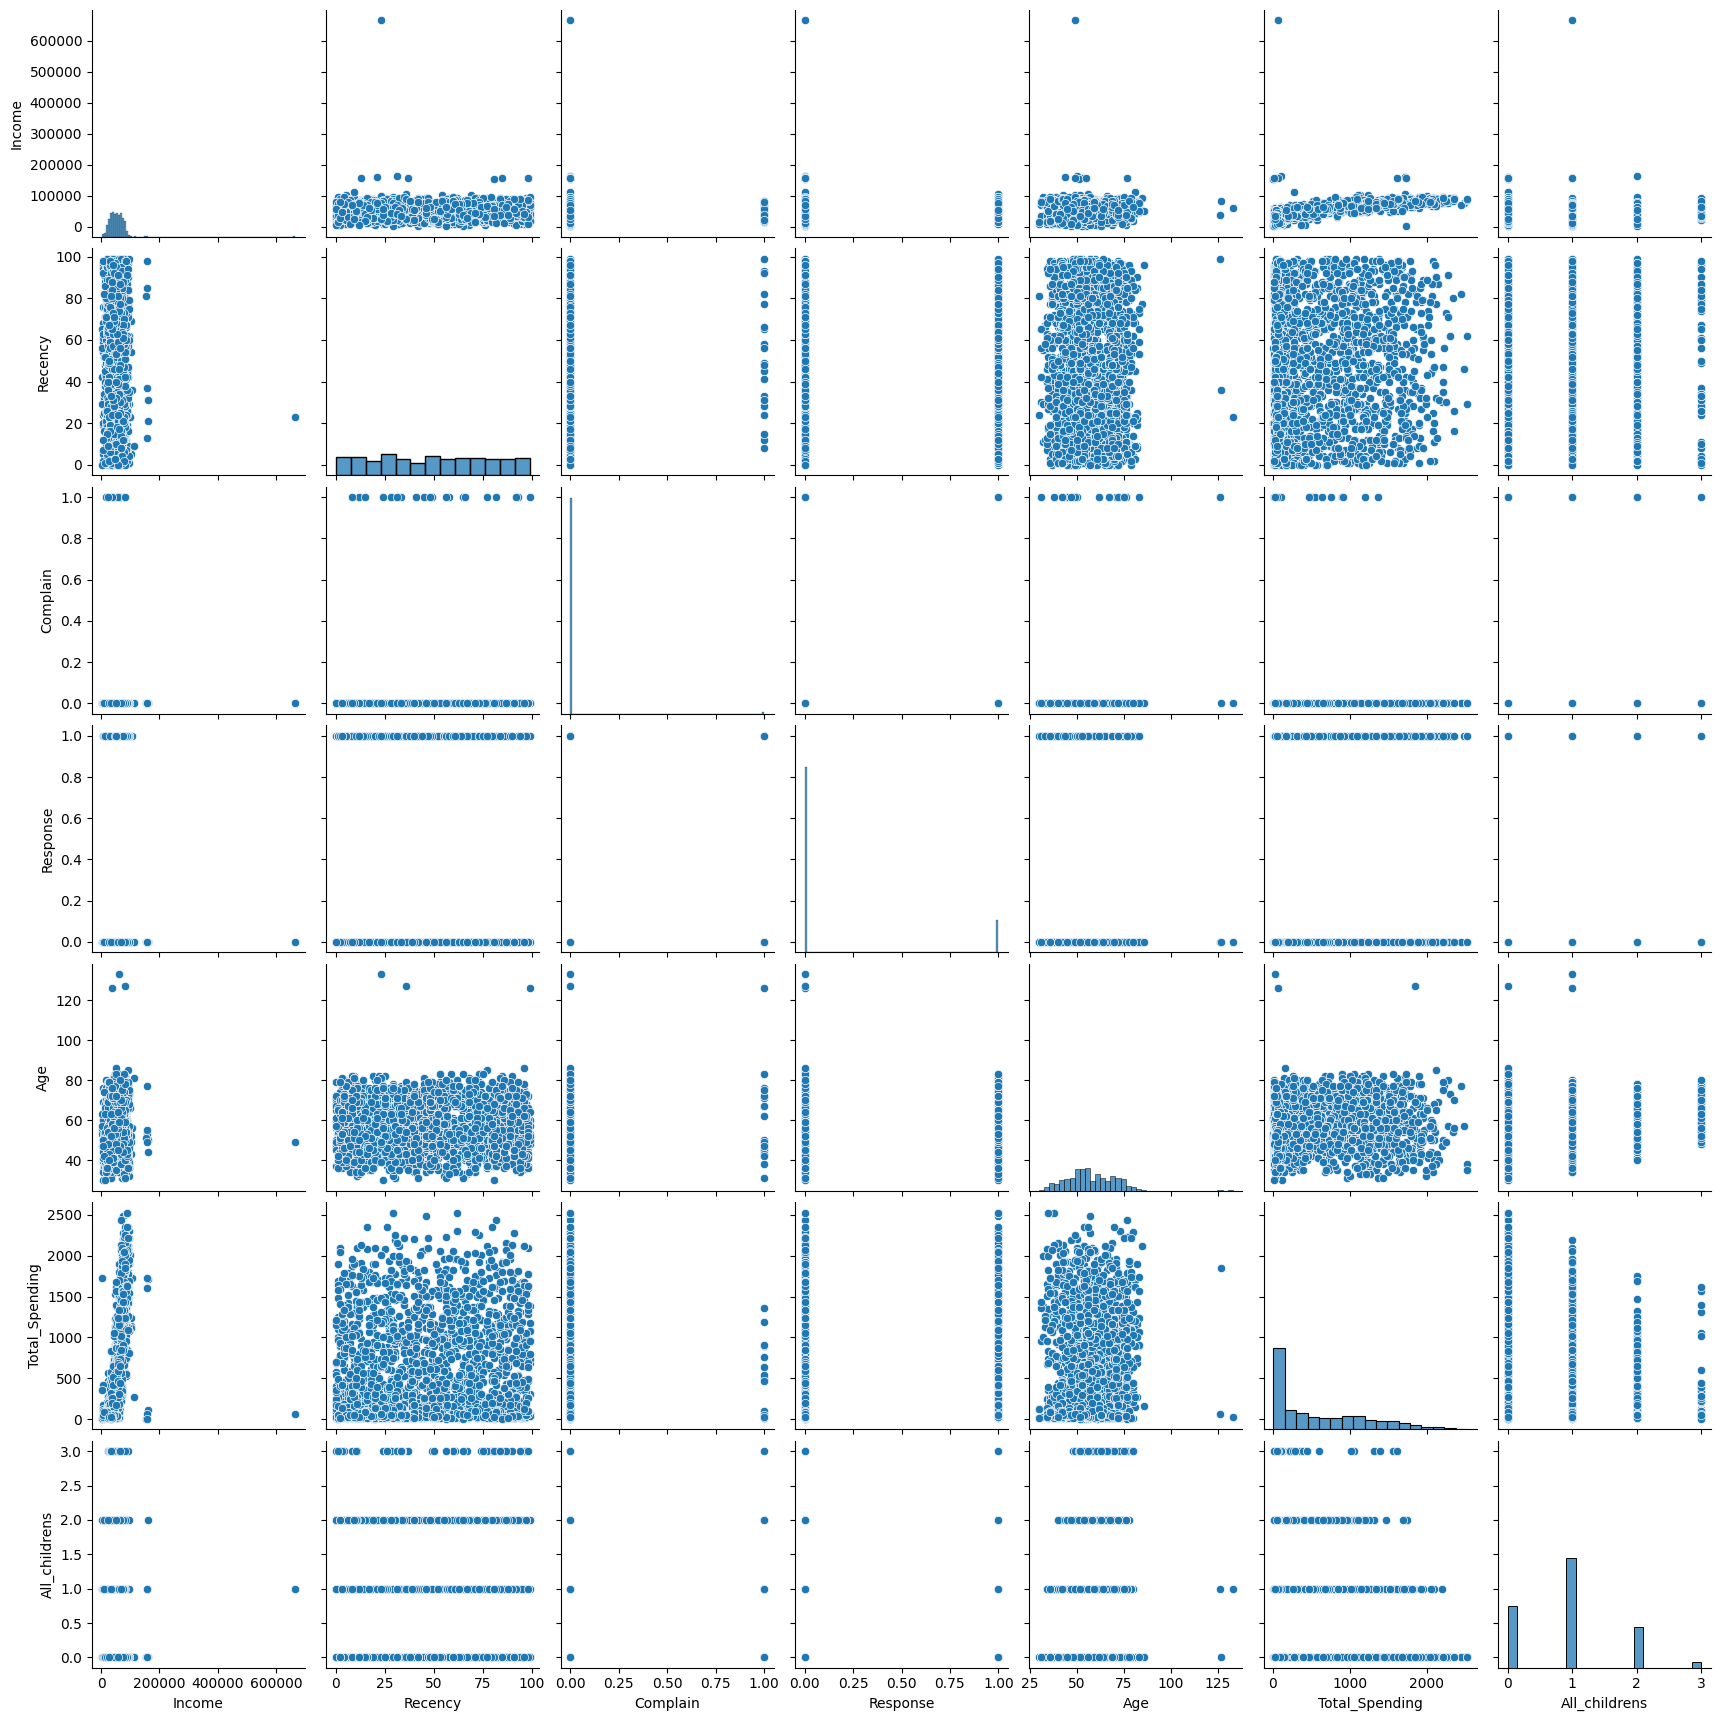

In [60]:
cols = ["Income", "Recency", "Complain", "Response", "Age", "Total_Spending", "All_childrens"]

# relative plots of some features: Pair plots
sns.pairplot(new_df[cols])

In [61]:
# Removing outliers
print("Data Size With Outliers", len(new_df))

new_df = new_df[(new_df["Age"] < 90)]
new_df = new_df[(new_df["Income"] < 600_000)]

print("Data Size Without Outliers", len(new_df))

Data Size With Outliers 2240
Data Size Without Outliers 2236


# Heatmap

<Axes: >

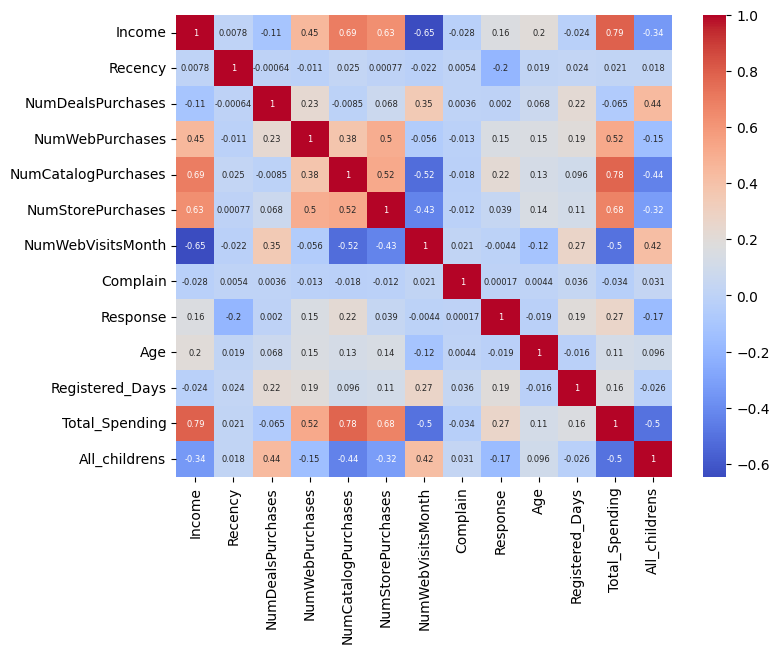

In [62]:
corr = new_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

### 4. Feature Encoding and Scaling

In [63]:
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_with"]
enc_cols = ohe.fit_transform(new_df[cat_cols])
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=new_df.index)
df_encoded = pd.concat([new_df.drop(columns=cat_cols), enc_df], axis=1)

In [64]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Registered_Days,Total_Spending,All_childrens,Education_Graduate,Education_Post Graduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


### 5. Scaling

In [65]:
X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Data Visualization

Text(0.5, 0.92, '3d Projection')

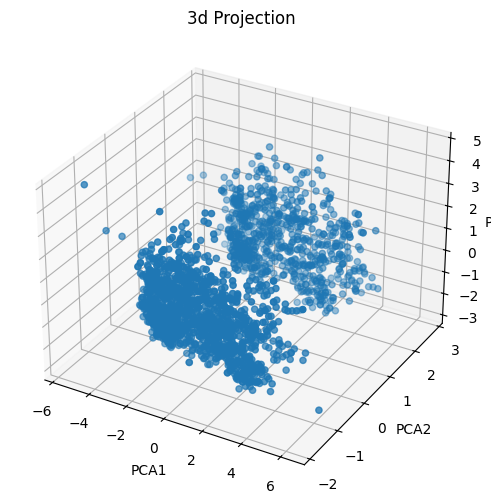

In [66]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

# Analyze K Value
### 1. Elbow Method

In [67]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("best K :", optimal_k)   

best K : 4


Text(0, 0.5, 'WCSS')

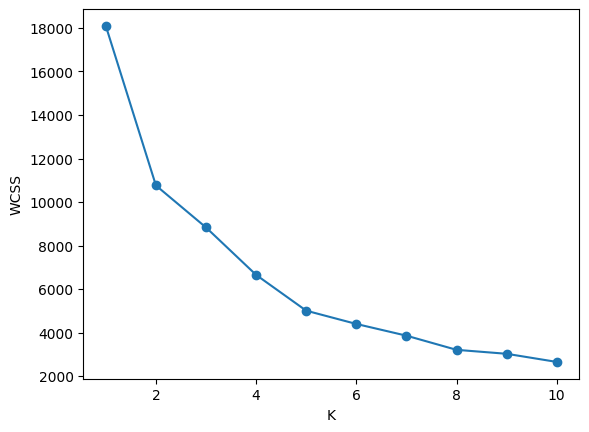

In [68]:
# PLot
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

Text(0, 0.5, 'Silhouette Score')

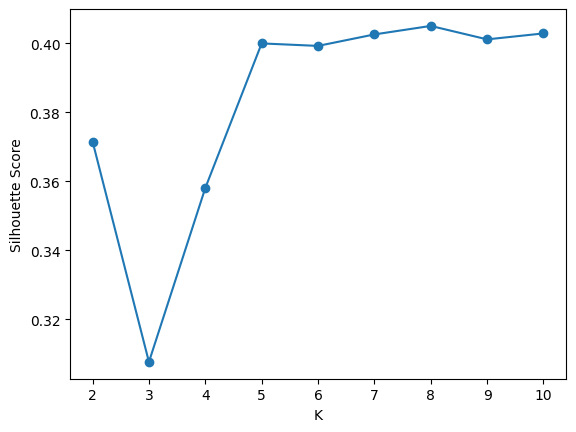

In [69]:
from sklearn.metrics import silhouette_score

scores=[]
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
# Plot
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")    
 

Text(0, 0.5, 'SS')

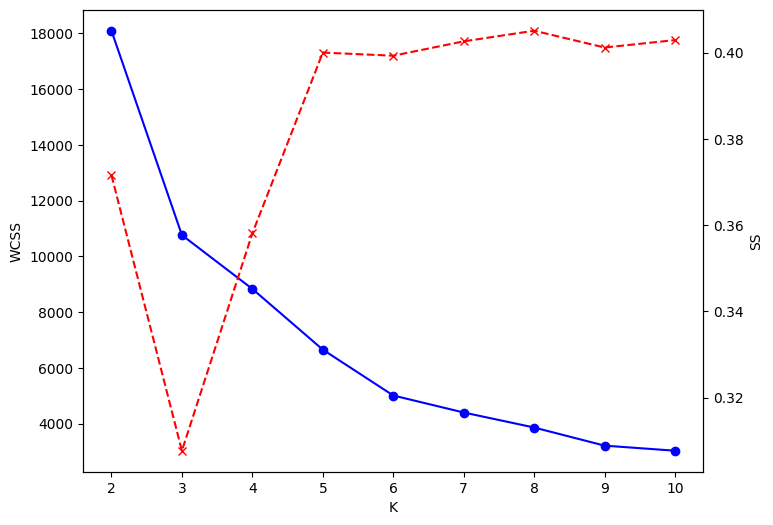

In [70]:
# Combined Plots

k_range = range(2, 11)
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# CLustering
### 1. KMeans Clustering

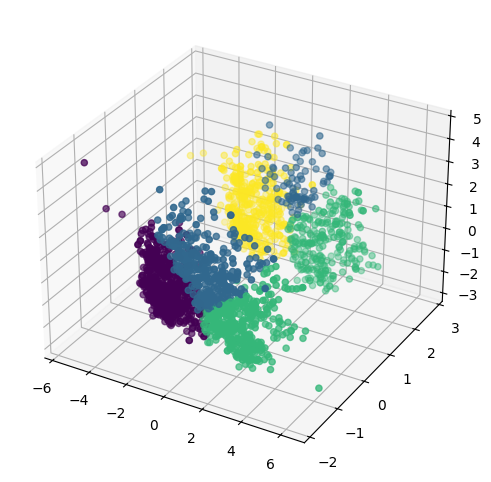

In [71]:
kmeans = KMeans(n_clusters = 4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

### 2. Agglomerative Clustering

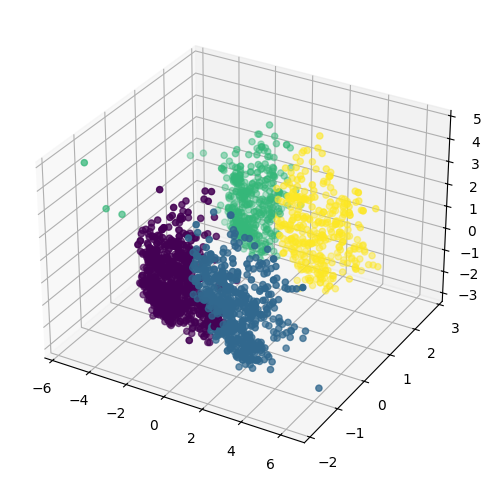

In [72]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

### The Agglomerative Clustering gave us better clusters than KMeans. ^

# Characterization Of Clusters

In [74]:

X["cluster"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Registered_Days,Total_Spending,All_childrens,Education_Graduate,Education_Post Graduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

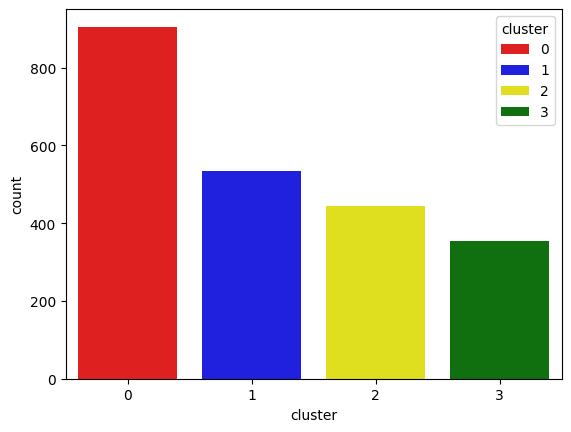

In [75]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

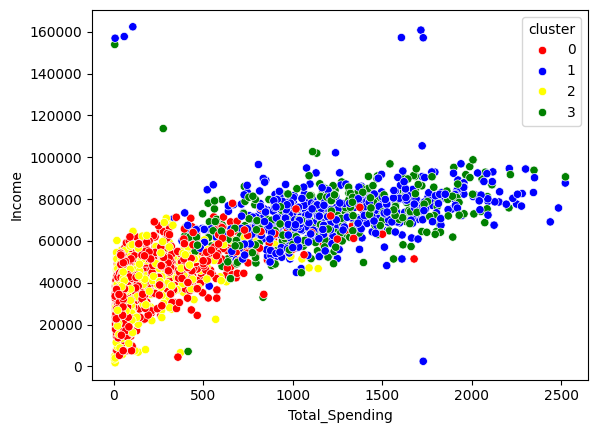

In [76]:
# Income and Spending Patterns
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [ ]:
# Cluster Summary


In [77]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Registered_Days  Total_Spending  All_childrens  \
cluste